### PROBLEM 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

files.upload()  # select aircraft_performance.csv

df = pd.read_csv('aircraft_performance.csv')
df.head()

Saving aircraft_performance.csv to aircraft_performance.csv


,Aircraft,Speed_kmh,FuelFlow_kgph
0,Cessna_172,226,24
1,Cessna_182,260,30
2,Piper_PA28,215,22
3,Diamond_DA40,240,26
4,Cirrus_SR20,250,29


In [3]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(df[['Speed_kmh', 'FuelFlow_kgph']])

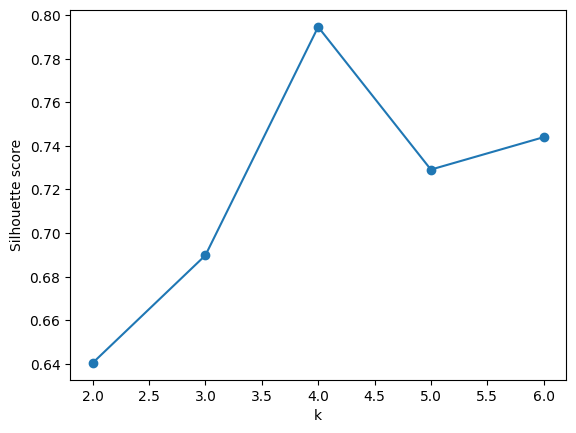

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=0)
    kmeans.fit(X)
    scores.append(silhouette_score(X, kmeans.labels_))

plt.plot(range(2, 7), scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.show()

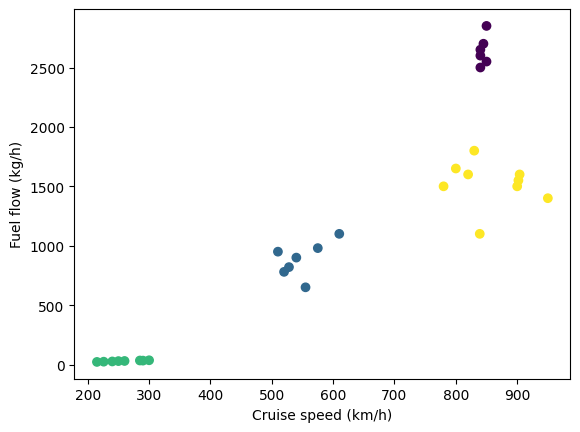

In [5]:
kmeans = KMeans(n_clusters=4, n_init='auto', random_state=0)
df['Cluster'] = kmeans.fit_predict(X)

plt.scatter(df['Speed_kmh'], df['FuelFlow_kgph'], c=df['Cluster'])
plt.xlabel('Cruise speed (km/h)')
plt.ylabel('Fuel flow (kg/h)')
plt.show()

### Choosing k
The silhouette scores were 0.64, 0.69, 0.80, 0.73 and 0.74 for k = 2 to 6. The score peaks at k = 4, so I chose 4 clusters.

### Cluster interpretation
- Slow, very low fuel flow (~260 km/h, ~30 kg/h)
- Medium speed, moderate fuel flow (~550 km/h, ~880 kg/h)
- Fast, medium-high fuel flow (~860 km/h, ~1500 kg/h)
- Fast, highest fuel flow (~845 km/h, ~2640 kg/h)

### PROBLEM 2

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

files.upload()  # select housing_prices.txt

cols = np.loadtxt('housing_prices.txt', delimiter=',', usecols=(0, 1), unpack=True)
X = np.transpose(np.array(cols[:-1]))
y = np.transpose(np.array(cols[-1:]))
m = y.size
X = np.insert(X, 0, 1, axis=1)

Saving housing_prices.txt to housing_prices.txt


In [7]:
def h(w, X):
    return np.dot(X, w)

def mse(w, X, y):
    return float((1./(2*m)) * np.dot((h(w, X) - y).T, (h(w, X) - y))[0, 0])

In [9]:
def minibatch_gd(X, y, batch_size, alpha=0.01, epochs=100):
    w = np.zeros((2, 1))
    J_values = []
    for _ in range(epochs):
        idx = np.random.permutation(m)  # shuffle each epoch
        for i in range(0, m, batch_size):
            b = idx[i:i + batch_size]
            Xb, yb = X[b], y[b]
            w = w - (alpha / len(b)) * Xb.T @ (h(w, Xb) - yb)
            J_values.append(mse(w, X, y))
    return w, J_values

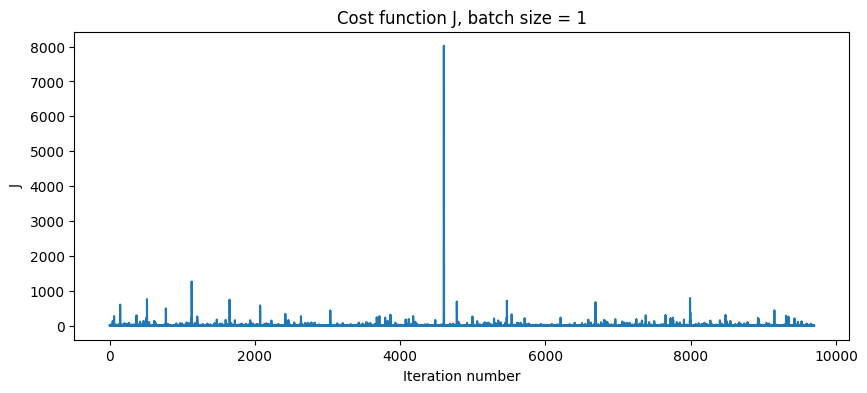

Batch size 1: w0 = -4.085, w1 = 0.887, predicted price = $101,034


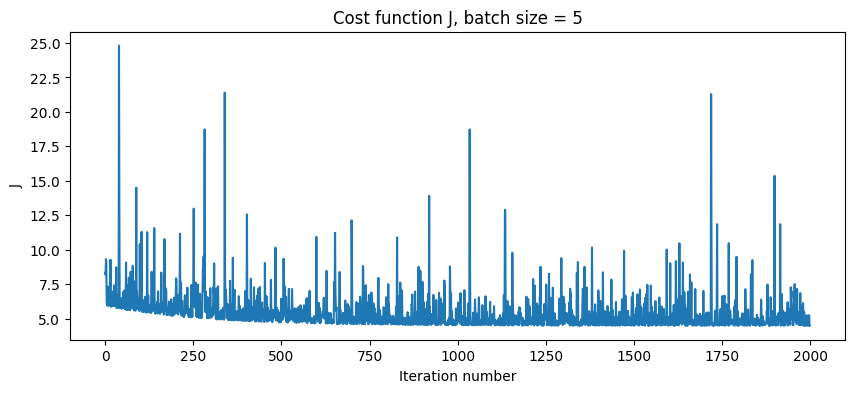

Batch size 5: w0 = -3.780, w1 = 1.193, predicted price = $153,087


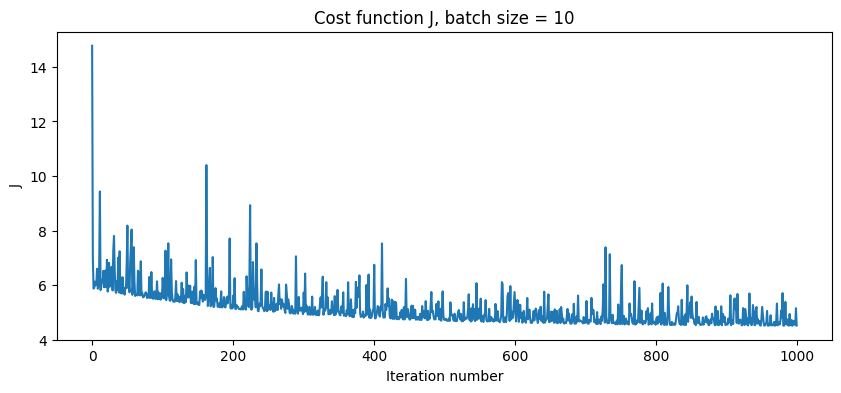

Batch size 10: w0 = -3.294, w1 = 1.148, predicted price = $150,681


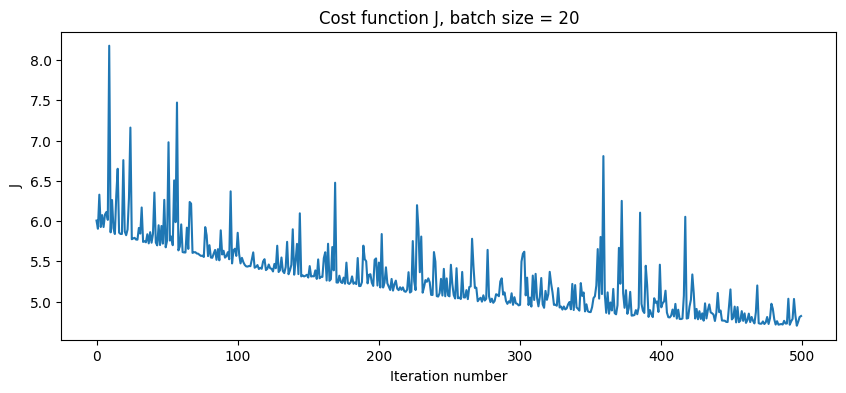

Batch size 20: w0 = -2.326, w1 = 1.090, predicted price = $151,148


In [10]:
for bs in [1, 5, 10, 20]:
    w, J_values = minibatch_gd(X, y, bs)

    plt.figure(figsize=(10, 4))
    plt.plot(J_values)
    plt.title(f'Cost function J, batch size = {bs}')
    plt.xlabel('Iteration number')
    plt.ylabel('J')
    plt.show()

    price = w[0, 0] + w[1, 0] * 16  # population 160,000 = 16 (in 10,000s)
    print(f'Batch size {bs}: w0 = {w[0,0]:.3f}, w1 = {w[1,0]:.3f}, predicted price = ${price*10000:,.0f}')

### What happens when batch size = 1?
With a batch size of 1, mini-batch GD becomes stochastic gradient descent where each update uses the gradient from a single random house. The cost function becomes very noisy. J jumps up and down from one iteration to the next, and it keeps bouncing around the minimum instead of settling into it. Each single-sample gradient is a rough estimate of the true gradient, so some steps go the wrong way. The final weights change from run to run, and they end up good, but not optimal

As the batch size increases (5, 10, 20), each gradient is averaged over more samples, so the J curve gets smoother and less noisey. Larger batches also make fewer updates per epoch, so for the same number of epochs J drops more slowly per epoch.

### PROBLEM 3

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

cancer = datasets.load_breast_cancer()
X = cancer['data']
y = cancer['target']  # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [12]:
lr = LogisticRegression(solver='lbfgs', max_iter=10000)
rfe = RFE(lr, n_features_to_select=2)
rfe.fit(X_train, y_train)

best = np.array(cancer.feature_names)[rfe.support_]
print('The best features are:', best)

The best features are: ['worst compactness' 'worst concavity']


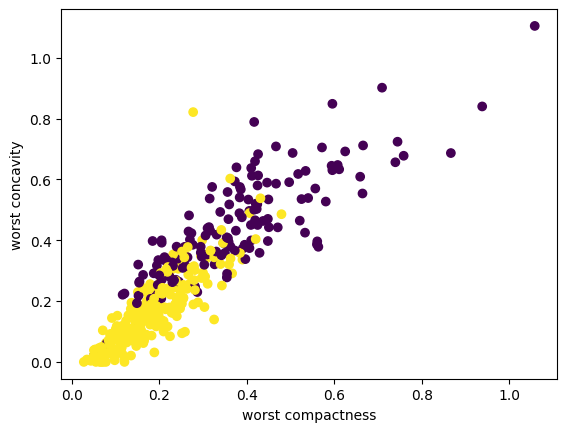

In [13]:
idx = np.where(rfe.support_)[0]
plt.scatter(X_train[:, idx[0]], X_train[:, idx[1]], c=y_train)
plt.xlabel(best[0])
plt.ylabel(best[1])
plt.show()

              precision    recall  f1-score   support

   malignant       0.80      0.71      0.76        63
      benign       0.84      0.90      0.87       108

    accuracy                           0.83       171
   macro avg       0.82      0.81      0.81       171
weighted avg       0.83      0.83      0.83       171



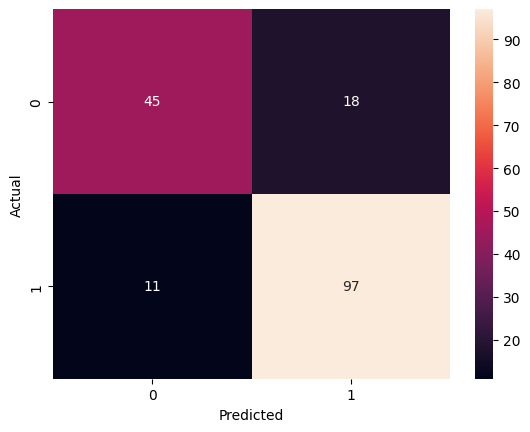

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rfe.predict(X_test)

print(classification_report(y_test, y_pred, target_names=cancer.target_names))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Findings
Recursive feature elimination selected **worst compactness** and **worst concavity** as the two best features. Both describe the shape of the cell nuclei, and malignant cells tend to have more irregular, concave boundaries.

Using only these two features, logistic regression achieved on the test set (171 samples):

| Metric | Malignant | Benign |
|---|---|---|
| Precision | 0.80 | 0.84 |
| Recall | 0.71 | 0.90 |
| F1 score | 0.76 | 0.87 |

**Accuracy = 83%**

- Confusion matrix: 45 malignant and 97 benign tumors were classified correctly, 18 malignant tumors were predicted benign, and 11 benign tumors were predicted malignant.
- The model is better at identifying benign tumors (recall 0.90) than malignant ones (recall 0.71).
- The 18 false negatives (malignant tumors called benign) are the most serious error in a medical setting, because those cancers would be missed.
- Two features capture most of the information, but they are not enough for a clinical-grade classifier. Adding more features or scaling the data would likely improve recall for the malignant class.

### PROBLEM 4

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = np.loadtxt('housing_prices.txt', delimiter=',')
X = data[:, 0:1]  # population (10,000s)
y = data[:, 1]    # price ($10,000s)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
for lr in [0.001, 0.01, 0.1]:
    tf.keras.utils.set_random_seed(3)
    model = Sequential()
    model.add(Dense(2, activation='relu', input_shape=[1]))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=optimizers.SGD(learning_rate=lr))
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, verbose=0)
    print(f'lr = {lr}: final val loss = {history.history["val_loss"][-1]:.2f}')

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


lr = 0.001: final val loss = 9.26
lr = 0.01: final val loss = 9.13
lr = 0.1: final val loss = 12.61


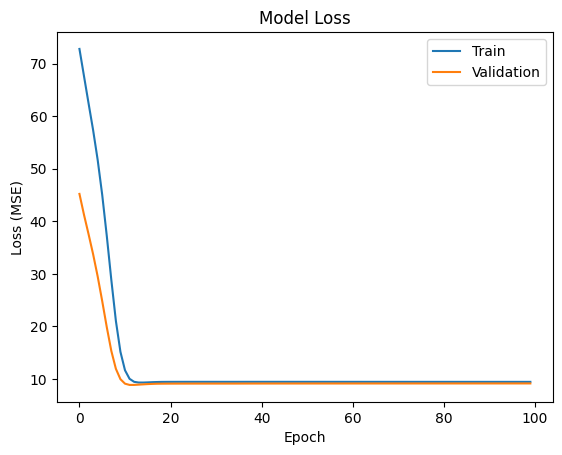

In [17]:
tf.keras.utils.set_random_seed(3)
model = Sequential()
model.add(Dense(2, activation='relu', input_shape=[1]))
model.add(Dense(1))
model.compile(loss='mse', optimizer=optimizers.SGD(learning_rate=0.01))

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, verbose=0)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [18]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test).ravel()
print('R^2 on validation set:', r2_score(y_test, y_pred))

price = model.predict(scaler.transform([[16.5]]))[0, 0]  # 165,000 people = 16.5
print(f'Predicted price for population 165,000: ${price*10000:,.0f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
R^2 on validation set: 0.5912086269641883
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted price for population 165,000: $165,211


### Choosing the learning rate and epochs
- lr = 0.001 was too slow.
- lr = 0.1 was too large. The loss ended up higher (~12.61)
- lr = 0.01 converged fastest to the lowest validation loss (~9.1), within about 10–20 epochs. 100 epochs is more than enough, and after convergence the curves are flat, so extra epochs don't help.

### Results
- R² on the validation set ≈ 0.59
- Predicted price for a city of 165,000 people ≈ $165,000.

### Loss trends
Both losses drop quickly in the first ~10 epochs as SGD moves the weights toward the minimum, then flatten out at nearly the same value (train ≈ 9.4, validation ≈ 9.1). The two curves stay close together, so the model is not overfitting.